В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

import statsmodels.api as sm


# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [3]:
cars_df = pd.read_csv('data/cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [4]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [5]:
cars_df.info()

display(cars_df.dtypes)

for col in cars_df.columns:
    unique_types = cars_df[col].map(type).value_counts()
    print(f'\n{col}:')
    print(unique_types)

categorical_cols = cars_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f'\n{col}: {cars_df[col].nunique()} унікальних значень')
    print(cars_df[col].value_counts())

numeric_cols = cars_df.select_dtypes(include=np.number).columns
binary_cols = [col for col in categorical_cols if cars_df[col].nunique() == 2]
ordinal_cols = ['Owner_Type']
nominal_multicategorical_cols = [
    col for col in categorical_cols
    if cars_df[col].nunique() > 2 and col not in ordinal_cols
]

print(f'''
В наборі даних {len(numeric_cols)} числових і {len(categorical_cols)} категоріальних колонок, з них:
- {len(binary_cols)} бінарні (мають лише 2 значення): {binary_cols}
- {len(nominal_multicategorical_cols)} мультикатегоріальні (більше 2х значень) зі значеннями, для яких немає відношення порядку: {nominal_multicategorical_cols}
- {len(ordinal_cols)} колонка, в якій можна встановити відношення порядку: {ordinal_cols}
''')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


Car_ID                int64
Brand                object
Model                object
Year                  int64
Kilometers_Driven     int64
Fuel_Type            object
Transmission         object
Owner_Type           object
Mileage               int64
Engine                int64
Power                 int64
Seats                 int64
Price                 int64
dtype: object


Car_ID:
Car_ID
<class 'int'>    100
Name: count, dtype: int64

Brand:
Brand
<class 'str'>    100
Name: count, dtype: int64

Model:
Model
<class 'str'>    100
Name: count, dtype: int64

Year:
Year
<class 'int'>    100
Name: count, dtype: int64

Kilometers_Driven:
Kilometers_Driven
<class 'int'>    100
Name: count, dtype: int64

Fuel_Type:
Fuel_Type
<class 'str'>    100
Name: count, dtype: int64

Transmission:
Transmission
<class 'str'>    100
Name: count, dtype: int64

Owner_Type:
Owner_Type
<class 'str'>    100
Name: count, dtype: int64

Mileage:
Mileage
<class 'int'>    100
Name: count, dtype: int64

Engine:
Engine
<class 'int'>    100
Name: count, dtype: int64

Power:
Power
<class 'int'>    100
Name: count, dtype: int64

Seats:
Seats
<class 'int'>    100
Name: count, dtype: int64

Price:
Price
<class 'int'>    100
Name: count, dtype: int64

Brand: 11 унікальних значень
Brand
Ford          11
Tata          11
Hyundai       11
BMW           10
Toyota        10
Audi          10
Volkswa

**Висновки**

В наборі даних 8 числових і 5 категоріальних колонок, з них:
- 2 бінарні (мають лише 2 значення): ['Fuel_Type', 'Transmission']
- 2 мультикатегоріальні (більше 2х значень) зі значеннями, для яких немає відношення порядку: ['Brand', 'Model']
- 1 колонка, в якій можна встановити відношення порядку: ['Owner_Type']


**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [6]:
X = cars_df.drop(columns='Price')
y = cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=12
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')


X_train shape: (80, 12)
X_test shape: (20, 12)
y_train shape: (80,)
y_test shape: (20,)


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [7]:
binary_cols = ['Fuel_Type', 'Transmission']

for col in binary_cols:
    most_common_value = X_train[col].value_counts().idxmax()
    X_train[f'{col}_Code'] = (X_train[col] == most_common_value).astype(int)
    X_test[f'{col}_Code'] = (X_test[col] == most_common_value).astype(int)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[['Brand']])

brand_train_encoded = ohe.transform(X_train[['Brand']])
brand_test_encoded = ohe.transform(X_test[['Brand']])

brand_encoded_cols = ohe.get_feature_names_out(['Brand'])

brand_train_df = pd.DataFrame(
    brand_train_encoded,
    columns=brand_encoded_cols,
    index=X_train.index
)

brand_test_df = pd.DataFrame(
    brand_test_encoded,
    columns=brand_encoded_cols,
    index=X_test.index
)

X_train = pd.concat([X_train, brand_train_df], axis=1)
X_test = pd.concat([X_test, brand_test_df], axis=1)

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']])
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])


Очікуваний результат після трансформацій:

In [8]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes,Price
Car_ID,1.000000,0.137027,-0.356614,0.100891,-0.089284,-0.006319,-0.063793,0.090537,-0.084381,0.089473,0.048335,-0.020240,-0.050809,0.016831,0.006797,-0.054463,-0.045431,-0.032926,0.011350,0.020129,0.038923,0.025560
Year,0.137027,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499,-0.233769
Kilometers_Driven,-0.356614,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772,-0.083951
Mileage,0.100891,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624,-0.638404
Engine,-0.089284,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106,0.710561
Power,-0.006319,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309,0.849137
Seats,-0.063793,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849,0.000979
Fuel_Type_Code,0.090537,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.281122,-0.110782
Transmission_Code,-0.084381,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.005886,0.680731
Brand_Audi,0.089473,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925,0.328858


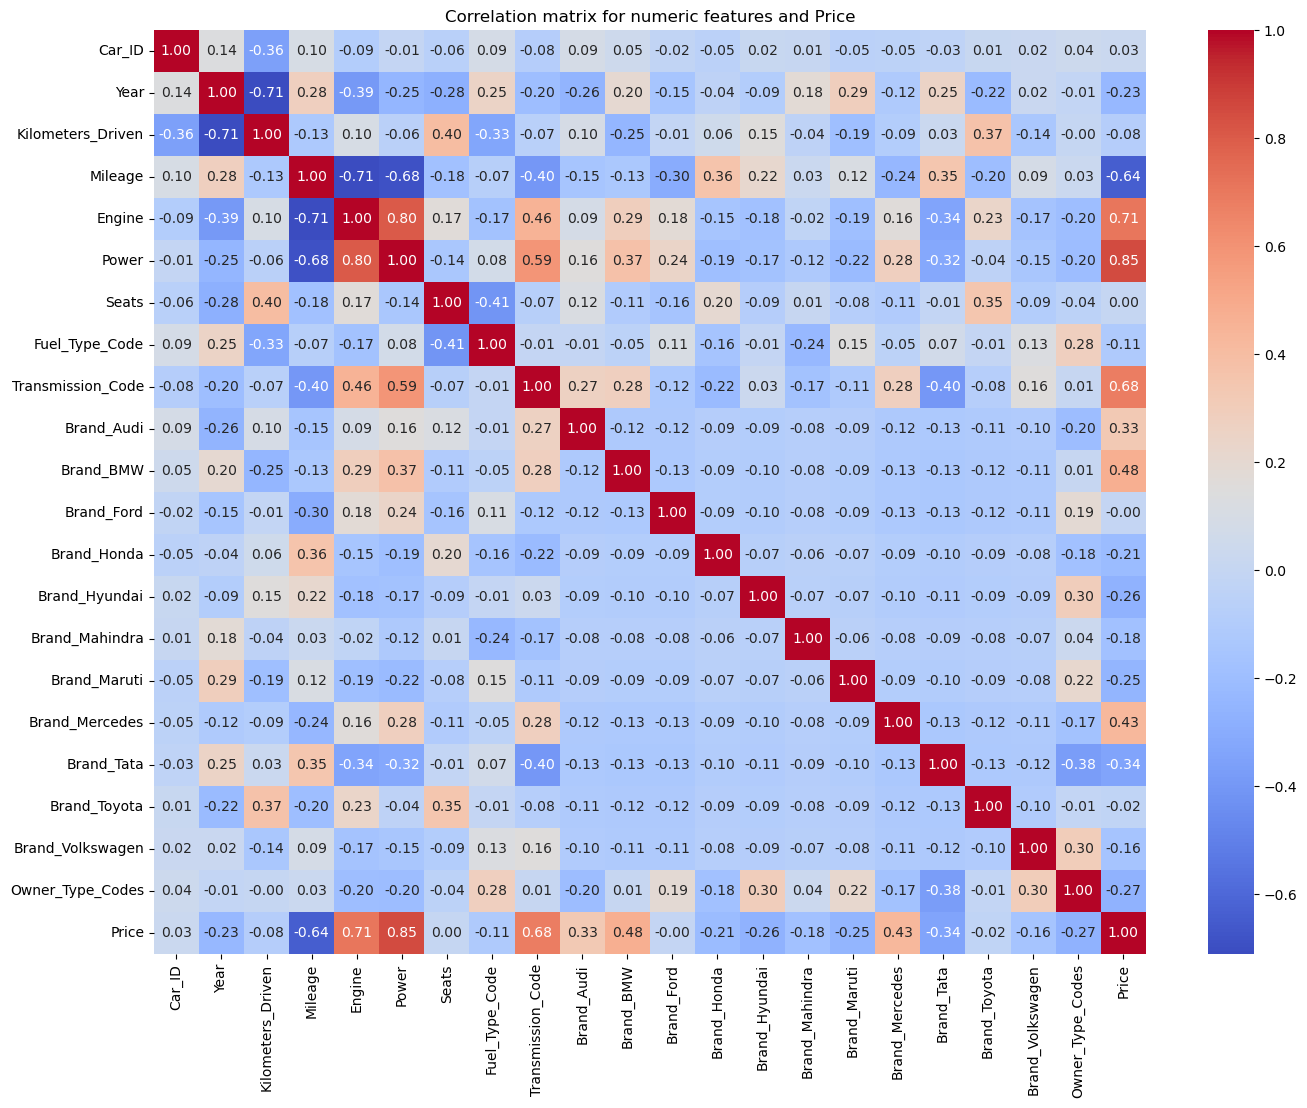

Кореляція ознак з Price:


Power                0.849137
Engine               0.710561
Transmission_Code    0.680731
Mileage             -0.638404
Brand_BMW            0.477522
Brand_Mercedes       0.431606
Brand_Tata          -0.341815
Brand_Audi           0.328858
Owner_Type_Codes    -0.265537
Brand_Hyundai       -0.263022
Brand_Maruti        -0.249737
Year                -0.233769
Brand_Honda         -0.209779
Brand_Mahindra      -0.178627
Brand_Volkswagen    -0.158742
Fuel_Type_Code      -0.110782
Kilometers_Driven   -0.083951
Car_ID               0.025560
Brand_Toyota        -0.023778
Brand_Ford          -0.004592
Seats                0.000979
Name: Price, dtype: float64

Колонки, які корелюють з цільовою змінною Price більш ніж на 0.5 за модулем:


Power                0.849137
Engine               0.710561
Transmission_Code    0.680731
Mileage             -0.638404
Name: Price, dtype: float64

In [9]:
X_train_numeric = X_train.select_dtypes(include=np.number)

train_corr_df = pd.concat([X_train_numeric, y_train], axis=1)
corr_matrix = train_corr_df.corr()

display(corr_matrix)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix for numeric features and Price')
plt.show()

price_corr = corr_matrix['Price'].drop('Price').sort_values(key=abs, ascending=False)
strong_price_corr = price_corr[price_corr.abs() > 0.5]

print('Кореляція ознак з Price:')
display(price_corr)

print('Колонки, які корелюють з цільовою змінною Price більш ніж на 0.5 за модулем:')
display(strong_price_corr)


**Висновок:**

З цільовою змінною Price більш ніж на 0.5 за модулем корелюють такі колонки:
['Power', 'Engine', 'Transmission_Code', 'Mileage']

Найсильніший позитивний зв'язок з Price мають ознаки Engine та Power.
Найсильніший негативний зв'язок з Price має Mileage.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

Train RMSE: 210293.58
Test RMSE: 258181.56


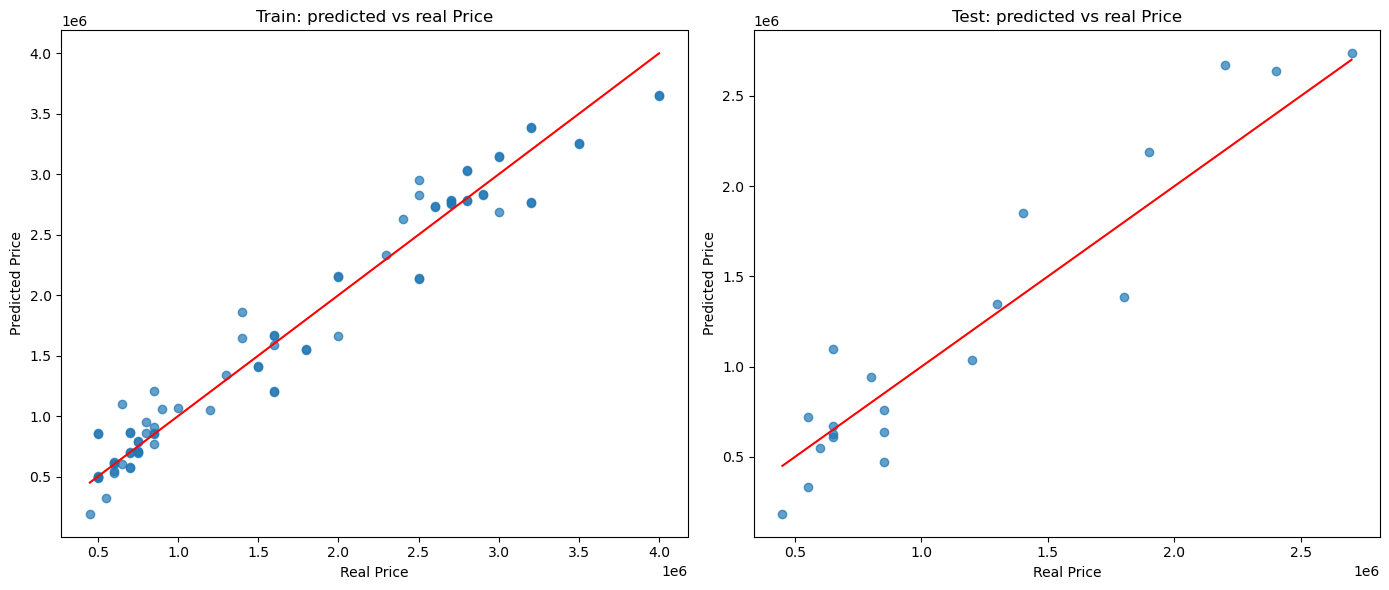

In [10]:
X_train_numeric = X_train.select_dtypes(include=np.number)
X_test_numeric = X_test.select_dtypes(include=np.number)

lin_reg = LinearRegression()
lin_reg.fit(X_train_numeric, y_train)

y_train_pred = lin_reg.predict(X_train_numeric)
y_test_pred = lin_reg.predict(X_test_numeric)

train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.7)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red')
plt.xlabel('Real Price')
plt.ylabel('Predicted Price')
plt.title('Train: predicted vs real Price')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel('Real Price')
plt.ylabel('Predicted Price')
plt.title('Test: predicted vs real Price')

plt.tight_layout()
plt.show()


**Висновки:**

Модель краще працює на тренувальних даних, ніж на тестових. Якщо Test RMSE помітно більший за Train RMSE, це може свідчити про перенавчання або недостатню узагальнювальну здатність моделі.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [11]:
scaler = StandardScaler()
scaler.fit(X_train_numeric)

X_train_scaled = scaler.transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_numeric.columns,
    index=X_train_numeric.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_numeric.columns,
    index=X_test_numeric.index
)

lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled, y_train)

scaled_coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': lin_reg_scaled.coef_,
    'abs_coefficient': np.abs(lin_reg_scaled.coef_)
}).sort_values('abs_coefficient', ascending=False)

display(scaled_coef_df)

print('Найвпливовіші ознаки за модулем коефіцієнта:')
display(scaled_coef_df.head(10))


,feature,coefficient,abs_coefficient
5,Power,496769.214899,496769.214899
16,Brand_Mercedes,210048.781148,210048.781148
10,Brand_BMW,208407.313783,208407.313783
9,Brand_Audi,205600.147769,205600.147769
7,Fuel_Type_Code,-183848.018909,183848.018909
13,Brand_Hyundai,-152304.863911,152304.863911
14,Brand_Mahindra,-140945.162904,140945.162904
3,Mileage,-131715.512030,131715.512030
11,Brand_Ford,-118209.450311,118209.450311
8,Transmission_Code,116693.768206,116693.768206


Найвпливовіші ознаки за модулем коефіцієнта:


,feature,coefficient,abs_coefficient
5,Power,496769.214899,496769.214899
16,Brand_Mercedes,210048.781148,210048.781148
10,Brand_BMW,208407.313783,208407.313783
9,Brand_Audi,205600.147769,205600.147769
7,Fuel_Type_Code,-183848.018909,183848.018909
13,Brand_Hyundai,-152304.863911,152304.863911
14,Brand_Mahindra,-140945.162904,140945.162904
3,Mileage,-131715.512030,131715.512030
11,Brand_Ford,-118209.450311,118209.450311
8,Transmission_Code,116693.768206,116693.768206


**Висновок:**

Найбільший позитивний вплив на Price мають ознаки з найбільшими додатними коефіцієнтами.
Найбільший негативний вплив на Price мають ознаки з найбільшими відʼємними коефіцієнтами.
Додатні коефіцієнти означають, що зі збільшенням ознаки прогнозована ціна зростає.
Відʼємні коефіцієнти означають, що зі збільшенням ознаки прогнозована ціна зменшується.
Зазвичай логічно, що Power, Engine та автоматична трансмісія збільшують ціну, а Mileage може зменшувати її, бо економніші авто часто мають менші двигуни і нижчу потужність, відповідно є ознакою менш потужного / менш преміального авто.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [12]:
X_train_scaled_sm = sm.add_constant(X_train_scaled)

sm_model = sm.OLS(y_train, X_train_scaled_sm).fit()

print(sm_model.summary())

p_values = sm_model.pvalues.drop('const')
significant_features = p_values[p_values < 0.05].index.tolist()

print()
print('Статистично значущі ознаки на рівні значущості 0.05:')
print(significant_features)


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           2.01e-33
Time:                        15:41:24   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.74e+0

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [13]:
significant_features_005 = sm_model.pvalues.drop('const')[sm_model.pvalues.drop('const') < 0.05].index.tolist()

X_train_significant_sm = sm.add_constant(X_train_scaled[significant_features_005])

sm_model_significant = sm.OLS(y_train, X_train_significant_sm).fit()

print(sm_model_significant.summary())
print()
print(f'R-squared моделі з усіма ознаками: {sm_model.rsquared:.3f}')
print(f'Adj. R-squared моделі з усіма ознаками: {sm_model.rsquared_adj:.3f}')
print(f'R-squared моделі тільки зі стат. значущими ознаками: {sm_model_significant.rsquared:.3f}')
print(f'Adj. R-squared моделі тільки зі стат. значущими ознаками: {sm_model_significant.rsquared_adj:.3f}')

print('Статистично значущі ознаки, використані в моделі:')
print(significant_features_005)


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           4.12e-39
Time:                        15:41:24   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

**Висновок:**

R2 та Adj. R-squared змінились незначно, їх значення близькі до моделі з усіма ознаками. Це означає, що модель зі статистично значущими ознаками є простішою, але майже не втрачає якість пояснення цільової змінної.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [15]:
features_pvalue_025 = sm_model.pvalues.drop('const')[sm_model.pvalues.drop('const') < 0.25].index.tolist()

X_train_pvalue_025_sm = sm.add_constant(X_train_scaled[features_pvalue_025])

sm_model_pvalue_025 = sm.OLS(y_train, X_train_pvalue_025_sm).fit()

print(sm_model_pvalue_025.summary())
print()
print(f'R-squared моделі з усіма ознаками: {sm_model.rsquared:.3f}')
print(f'Adj. R-squared моделі з усіма ознаками: {sm_model.rsquared_adj:.3f}')
print(f'R-squared моделі тільки зі стат. значущими ознаками p-value < 0.05: {sm_model_significant.rsquared:.3f}')
print(
    f'Adj. R-squared моделі тільки зі стат. значущими ознаками p-value < 0.05: {sm_model_significant.rsquared_adj:.3f}')
print(f'R-squared моделі з ознаками p-value < 0.25: {sm_model_pvalue_025.rsquared:.3f}')
print(f'Adj. R-squared моделі з ознаками p-value < 0.25: {sm_model_pvalue_025.rsquared_adj:.3f}')

print()
print('Ознаки, використані в моделі з p-value < 0.25:')
print(features_pvalue_025)


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           4.85e-38
Time:                        15:43:55   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.65e+0

**Висновок:**

R2 та Adj. R-squared для моделі з p-value < 0.25 майже не змінюються порівняно з моделлю на всіх ознаках із завдання 8.
Порівняно з моделлю тільки на ознаках p-value < 0.05 модель з p-value < 0.25 може мати трохи вищий R2, але вона менш проста.
Для використання я б залишила модель з ознаками p-value < 0.05 (її Adj. R-squared близький до інших моделей), бо вона простіша та містить тільки статистично значущі ознаки.